# _4.2.4. (multi-class) classification using TabNet_

The main topics of the current notebook is to focus on applying TabNet to the problem of anomaly detection, i.e., categorizing anomalies into distinct classes : reorder, duplicate, corrupt anomaly or simply normal case.

#### _a. Load Data_

Recall, the dataset was already cleaned and normalized _(using StandardScaler)_. Columns with zero or near-zero variance deleted.

In [1]:
!jupyter nbextension enable --py widgetsnbextension

Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: ok


In [2]:
import pandas as pd
import numpy as np
import os
import time
import torch

from matplotlib import pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from sklearn.metrics import silhouette_score, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.model_selection import train_test_split

from pytorch_tabnet.tab_model import TabNetClassifier

%matplotlib inline

In [3]:
scaled_new_dataset = "data/scaled_new_godash_dataset.csv"
scaled_new_df = pd.read_csv(scaled_new_dataset, index_col=0)

scaled_new_df.head(2)

,Seg_id,Arr_time,Del_Time,Stall_Dur,Rep_Level,Del_Rate,Act_Rate,Byte_Size,Buff_Level,Width,...,Yu,algo,nb_nodes,mos,MOS,mos_label,anomaly,level,tag2,tag
0,-1.697807,-0.445033,-0.204334,-0.164204,-1.294465,-1.160341,-1.160370,-1.160361,-0.833377,-1.247338,...,0.360347,-1.462647,0.524565,-1.043858,-0.045817,bad,0,-1.083746,False,0
1,-1.640070,-0.441006,-0.198458,-0.164204,-1.294465,-0.396335,-1.008632,-1.008502,-0.575036,-1.247338,...,0.360347,-1.462647,0.524565,-1.114816,-0.045817,bad,0,-1.083746,False,0


In [4]:
# Recall, all the following have been deleted --> ['Seg_Dur', 'Codec', 'FPS', 'Protocol']
all_features = ['Seg_id', 'Arr_time', 'Del_Time', 'Stall_Dur', 'Rep_Level', 'Del_Rate',
                'Act_Rate', 'Byte_Size', 'Buff_Level', 'Width',
                'Height', 'Play_Pos', 'RTT', 'P.1203', 'Clae',
                'Duanmu', 'Yin', 'Yu', 'algo', 'nb_nodes', 'mos', 'MOS', 'mos_label', 
                'anomaly', 'level', 'tag2', 'tag']

new_df = scaled_new_df [all_features]
selected_features = all_features[:-4]
target = "anomaly"

In [5]:
dataset_name = 'new_godash_dataset'
train = new_df
n_total = len(train)
print ("n_total = ", n_total)
print ("nb features =", len(train.columns))
print ("nan values =", train.isna().sum().sum())

n_total =  85596
nb features = 27
nan values = 0


#### _b. Label Encode target y_

The basic Idea here is to see the problem as a binary classification problem. 

The population is already devided into different anomalies tag using "anomaly" column.

In [6]:
train[target].value_counts(normalize=True)

0    0.253049
1    0.252348
2    0.252348
3    0.242254
Name: anomaly, dtype: float64

#### _c. Split_

In [7]:
train_val_indices, test_indices = train_test_split(range(n_total), test_size=0.2, random_state=0)
train_indices, valid_indices = train_test_split(train_val_indices, test_size=0.2 / 0.6, random_state=0)

# This is a generic pipeline but actually no categorical features are available for this dataset
unused_feat = ["mos_label", 'anomaly', 'level', 'tag']
features = [ col for col in selected_features if col not in unused_feat+[target]] 

X_train = train[features].values[train_indices]
y_train = train[target].values[train_indices]

X_valid = train[features].values[valid_indices]
y_valid = train[target].values[valid_indices]

X_test = train[features].values[test_indices]
y_test = train[target].values[test_indices]

print ("X_train (shape) = ", X_train.shape, "--> ", round((X_train.shape[0]/train.shape[0])*100,2), "%")
print ("X_valid (shape) = ", X_valid.shape, "--> ", round((X_valid.shape[0]/train.shape[0])*100,2), "%")
print ("X_test (shape)  = ", X_test.shape, "--> ", round((X_test.shape[0]/train.shape[0])*100,2), "%\n\n")

print ("y_train (shape) = ", y_train.shape)
print ("y_valid (shape) = ", y_valid.shape)
print ("y_test (shape)  = ", y_test.shape)

X_train (shape) =  (45650, 22) -->  53.33 %
X_valid (shape) =  (22826, 22) -->  26.67 %
X_test (shape)  =  (17120, 22) -->  20.0 %


y_train (shape) =  (45650,)
y_valid (shape) =  (22826,)
y_test (shape)  =  (17120,)


##### _Categorical features_

We need to identify categorical features before training in Tabnet

In [8]:
nunique = train.nunique()
types = train.dtypes

categorical_columns = []
categorical_dims =  {}
for col in train.columns:
    if types[col] == 'object' or nunique[col] < 200:
        print(col, train[col].nunique())
        l_enc = LabelEncoder()
        train[col] = train[col].fillna("VV_likely")
        train[col] = l_enc.fit_transform(train[col].values)
        categorical_columns.append(col)
        categorical_dims[col] = len(l_enc.classes_)

Seg_id 60
Rep_Level 8
Width 6
Height 6
Play_Pos 60
algo 6
nb_nodes 10
MOS 5
mos_label 5
anomaly 4
level 7
tag2 2
tag 19


In [9]:
cat_idxs = [ i for i, f in enumerate(features) if f in categorical_columns]
cat_dims = [ categorical_dims[f] for i, f in enumerate(features) if f in categorical_columns]

pd.DataFrame({"cathegorical_features" : np.array(features)[cat_idxs],\
              "feat_index" : cat_idxs,\
              "cat_dimention" : cat_dims })

,cathegorical_features,feat_index,cat_dimention
0,Seg_id,0,60
1,Rep_Level,4,8
2,Width,9,6
3,Height,10,6
4,Play_Pos,11,60
5,algo,18,6
6,nb_nodes,19,10
7,MOS,21,5


In [10]:
X_train = train[features].values[train_indices]
y_train = train[target].values[train_indices]

X_valid = train[features].values[valid_indices]
y_valid = train[target].values[valid_indices]

X_test = train[features].values[test_indices]
y_test = train[target].values[test_indices]

print ("X_train (shape) = ", X_train.shape, "--> ", round((X_train.shape[0]/train.shape[0])*100,2), "%")
print ("X_valid (shape) = ", X_valid.shape, "--> ", round((X_valid.shape[0]/train.shape[0])*100,2), "%")
print ("X_test (shape)  = ", X_test.shape, "--> ", round((X_test.shape[0]/train.shape[0])*100,2), "%\n\n")

print ("y_train (shape) = ", y_train.shape)
print ("y_valid (shape) = ", y_valid.shape)
print ("y_test (shape)  = ", y_test.shape)

X_train (shape) =  (45650, 22) -->  53.33 %
X_valid (shape) =  (22826, 22) -->  26.67 %
X_test (shape)  =  (17120, 22) -->  20.0 %


y_train (shape) =  (45650,)
y_valid (shape) =  (22826,)
y_test (shape)  =  (17120,)


##### _Grouped features_

You can now specify groups of feature which will share a common attention.

This may be very usefull for features comming from a same preprocessing technique like PCA for example.

In [11]:
grouped_features = [[0, 1, 2], [8, 9, 10]]
pd.DataFrame({"group_01" : np.array(features)[grouped_features[0]],\
              "group_02" : np.array(features)[grouped_features[1]]})

,group_01,group_02
0,Seg_id,Buff_Level
1,Arr_time,Width
2,Del_Time,Height


#### _d. Check CUDA support_

In [12]:
print ("Is CUDA available :", torch.cuda.is_available())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print ("Device :", DEVICE)

Is CUDA available : True
Device : cuda


In [13]:
os.environ['CUDA_VISIBLE_DEVICES'] = f"1"

print ("Is Torsh available --> ", torch.cuda.is_available())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE 

Is Torsh available -->  True


'cuda'

In [14]:
torch.__version__

'1.9.0+cu111'

In [15]:
from pytorch_tabnet.augmentations import ClassificationSMOTE
aug = ClassificationSMOTE(p=0.2)

### _e. (multi-class) classification using TabNet_

While traditional vanilla _**neural networks**_ can be powerful, they may encounter certain pitfalls in the context of anomaly detection _(motivating the exploration of alternative architectures)_ 

This includes :

-  Lack of support of Sequential/Tabular Data 

-  Lack of Interpretability


Developed by Google Cloud AI researchers, _**TabNet**_ introduces innovations that make it well-suited for tasks involving datasets with rows and columns, and where interpretability is a critical requirement.


<br>

<div style="float: center;"><img  src="docs\pics\tabnet_google.png"  alt="binary_nn"  width="400"/>
</div>

</br>

We used [**_dreamquark-ai/tabnet_**](https://github.com/dreamquark-ai/tabnet), a **_PyTorsh_** implementation of tabnet based on the [[original paper]](https://arxiv.org/pdf/1908.07442.pdf). 

As an hyper-parameter-tuning, we have to choose between _**AUC**_ vs _**logloss**_ as an _**evaluation metric**_. 

### _1. Using AUC_

In [16]:
clf = TabNetClassifier(
    n_d=64, n_a=64, n_steps=5,
    gamma=1.5, n_independent=2, n_shared=2,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=1,
    lambda_sparse=1e-4, momentum=0.3, clip_value=2.,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params = {"gamma": 0.95, "step_size": 20},
    scheduler_fn=torch.optim.lr_scheduler.StepLR, epsilon=1e-15,
    device_name = DEVICE
)

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [17]:
X_valid.shape

(22826, 22)

In [18]:
max_epochs = 100 if not os.getenv("CI", False) else 2
from pytorch_tabnet.augmentations import ClassificationSMOTE
aug = ClassificationSMOTE(p=0.2)

clf.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_name=['train', 'valid'],
    max_epochs=max_epochs, patience=100,
    batch_size=3303, virtual_batch_size=256,
    # batch_size=1024, virtual_batch_size=256,    
    augmentations=aug
) 

epoch 0  | loss: 1.51624 | train_accuracy: 0.51476 | valid_accuracy: 0.51012 |  0:00:05s
epoch 1  | loss: 1.04802 | train_accuracy: 0.53711 | valid_accuracy: 0.53684 |  0:00:10s
epoch 2  | loss: 0.99143 | train_accuracy: 0.59634 | valid_accuracy: 0.5977  |  0:00:16s
epoch 3  | loss: 0.94556 | train_accuracy: 0.59682 | valid_accuracy: 0.59305 |  0:00:21s
epoch 4  | loss: 0.91243 | train_accuracy: 0.59792 | valid_accuracy: 0.59699 |  0:00:26s
epoch 5  | loss: 0.89993 | train_accuracy: 0.61023 | valid_accuracy: 0.60887 |  0:00:31s
epoch 6  | loss: 0.87364 | train_accuracy: 0.62057 | valid_accuracy: 0.61702 |  0:00:36s
epoch 7  | loss: 0.8555  | train_accuracy: 0.63823 | valid_accuracy: 0.63822 |  0:00:41s
epoch 8  | loss: 0.85962 | train_accuracy: 0.6306  | valid_accuracy: 0.63323 |  0:00:46s
epoch 9  | loss: 0.8524  | train_accuracy: 0.63249 | valid_accuracy: 0.62985 |  0:00:51s
epoch 10 | loss: 0.8464  | train_accuracy: 0.6354  | valid_accuracy: 0.63607 |  0:00:56s
epoch 11 | loss: 0.84

epoch 93 | loss: 0.63365 | train_accuracy: 0.78668 | valid_accuracy: 0.78441 |  0:07:49s
epoch 94 | loss: 0.61391 | train_accuracy: 0.7239  | valid_accuracy: 0.72124 |  0:07:53s
epoch 95 | loss: 0.60521 | train_accuracy: 0.72375 | valid_accuracy: 0.71883 |  0:07:58s
epoch 96 | loss: 0.59623 | train_accuracy: 0.74296 | valid_accuracy: 0.74319 |  0:08:03s
epoch 97 | loss: 0.59433 | train_accuracy: 0.71941 | valid_accuracy: 0.71559 |  0:08:08s
epoch 98 | loss: 0.58102 | train_accuracy: 0.74414 | valid_accuracy: 0.73828 |  0:08:13s
epoch 99 | loss: 0.57736 | train_accuracy: 0.69599 | valid_accuracy: 0.69097 |  0:08:18s
Stop training because you reached max_epochs = 100 with best_epoch = 89 and best_valid_accuracy = 0.78757


C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


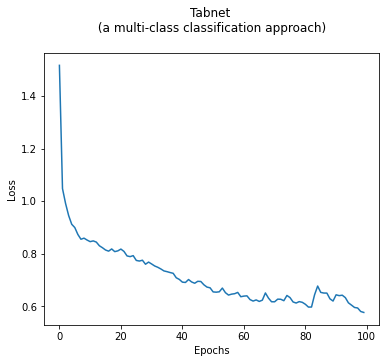

In [19]:
# plot losses
plt.figure(figsize=(6,5))
plt.plot(clf.history['loss'])
plt.title('Tabnet \n (a multi-class classification approach) \n ')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

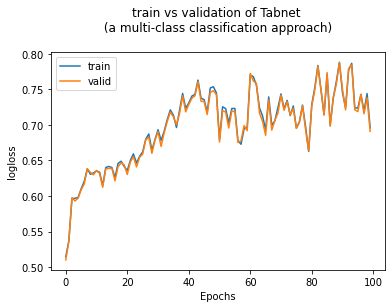

In [20]:
plt.plot(clf.history['train_accuracy'], label="train")
plt.plot(clf.history['valid_accuracy'], label="valid")
plt.title('train vs validation of Tabnet \n (a multi-class classification approach) \n ')
plt.xlabel('Epochs')
plt.ylabel('logloss')
plt.legend()

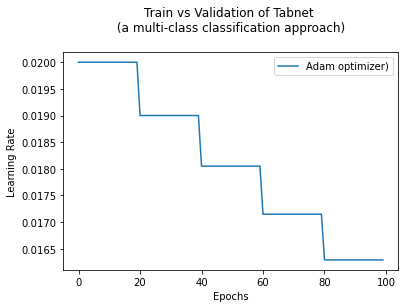

In [21]:
# plot learning rates
plt.plot(clf.history['lr'], label="Adam optimizer)")
plt.title('Train vs Validation of Tabnet \n (a multi-class classification approach) \n ')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.legend()

##### _Evaluate_

In [78]:
# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_valid = clf.predict(X_valid)
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

# Calculate accuracy
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Validation Accuracy:", valid_accuracy)
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Validation Accuracy: 0.7875668097783229
Train Accuracy: 0.7882146768893756
Test Accuracy: 0.7893691588785047


Evaluate using test set :

In [79]:
# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_test = clf.predict(X_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.7893691588785047


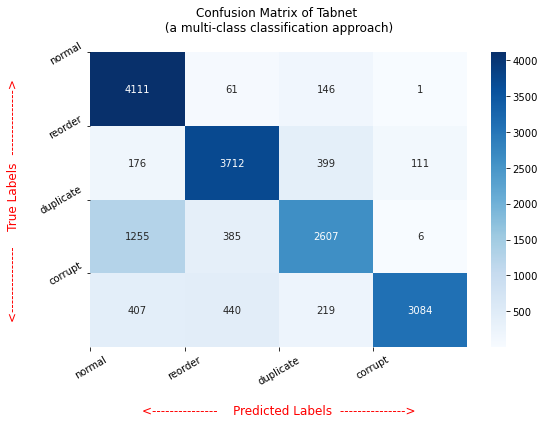

In [80]:
from sklearn.metrics import confusion_matrix, classification_report


# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

import seaborn as sns
import matplotlib.pyplot as plt

labeled_classes = ['normal','reorder', 'duplicate','corrupt']
classes = np.unique(y_train) 

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labeled_classes, rotation=30)
plt.yticks(classes, labeled_classes, rotation=30)
plt.xlabel("<---------------    Predicted Labels  --------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<---------------    True Labels  --------------->",  fontsize=12, color="red", labelpad=18)
plt.title('Confusion Matrix of Tabnet \n (a multi-class classification approach) \n ')
plt.tight_layout()
plt.show()

In [81]:
# Display a classification report
print("                  TabNet Classification Report")
print("                (a multi-class classification approach) \n")
print(classification_report(y_test, y_pred_test))

                  TabNet Classification Report
                (a multi-class classification approach) 

              precision    recall  f1-score   support

           0       0.69      0.95      0.80      4319
           1       0.81      0.84      0.83      4398
           2       0.77      0.61      0.68      4253
           3       0.96      0.74      0.84      4150

    accuracy                           0.79     17120
   macro avg       0.81      0.79      0.79     17120
weighted avg       0.81      0.79      0.79     17120



##### _Global explainability : feat importance summing to 1_

In [82]:
scorez = clf.feature_importances_

# Sort features based on their absolute coefficients
feature_importance = pd.DataFrame({'feature': features, 'score': scorez})
feature_importance = feature_importance.sort_values(by='score', ascending=False)
feature_importance['f_indice'] = feature_importance.index
feature_importance = feature_importance.reset_index().drop(["index"], axis=1)
feature_importance['rank'] = feature_importance.index+1
feature_importance.head(20)

,feature,score,f_indice,rank
0,Del_Rate,0.268607,5,1
1,Clae,0.117919,14,2
2,P.1203,0.106430,13,3
3,nb_nodes,0.095982,19,4
4,Del_Time,0.074605,2,5
5,Yu,0.066285,17,6
6,Byte_Size,0.055529,7,7
7,RTT,0.053716,12,8
8,Height,0.032967,10,9
9,Buff_Level,0.031736,8,10


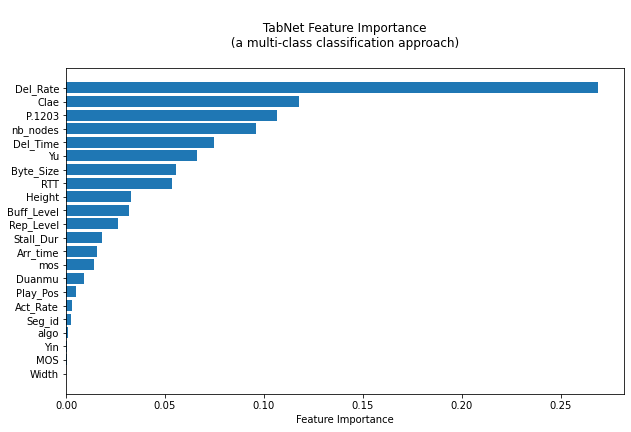

In [83]:
feature_importance = clf.feature_importances_

# Map feature names to importance scores
feature_names = [features[i] for i in range(X_train.shape[1])]
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1])

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), [importance for feature, importance in sorted_features], align="center")
plt.yticks(range(len(sorted_features)), [feature for feature, importance in sorted_features])
plt.xlabel("Feature Importance")
plt.title("\n TabNet Feature Importance \n (a multi-class classification approach) \n")
plt.show()

#### _Local explainability and masks_

In [29]:
explain_matrix, masks = clf.explain(X_test)
print (masks.keys())
masks[0][:50].shape

dict_keys([0, 1, 2, 3, 4])


(50, 22)

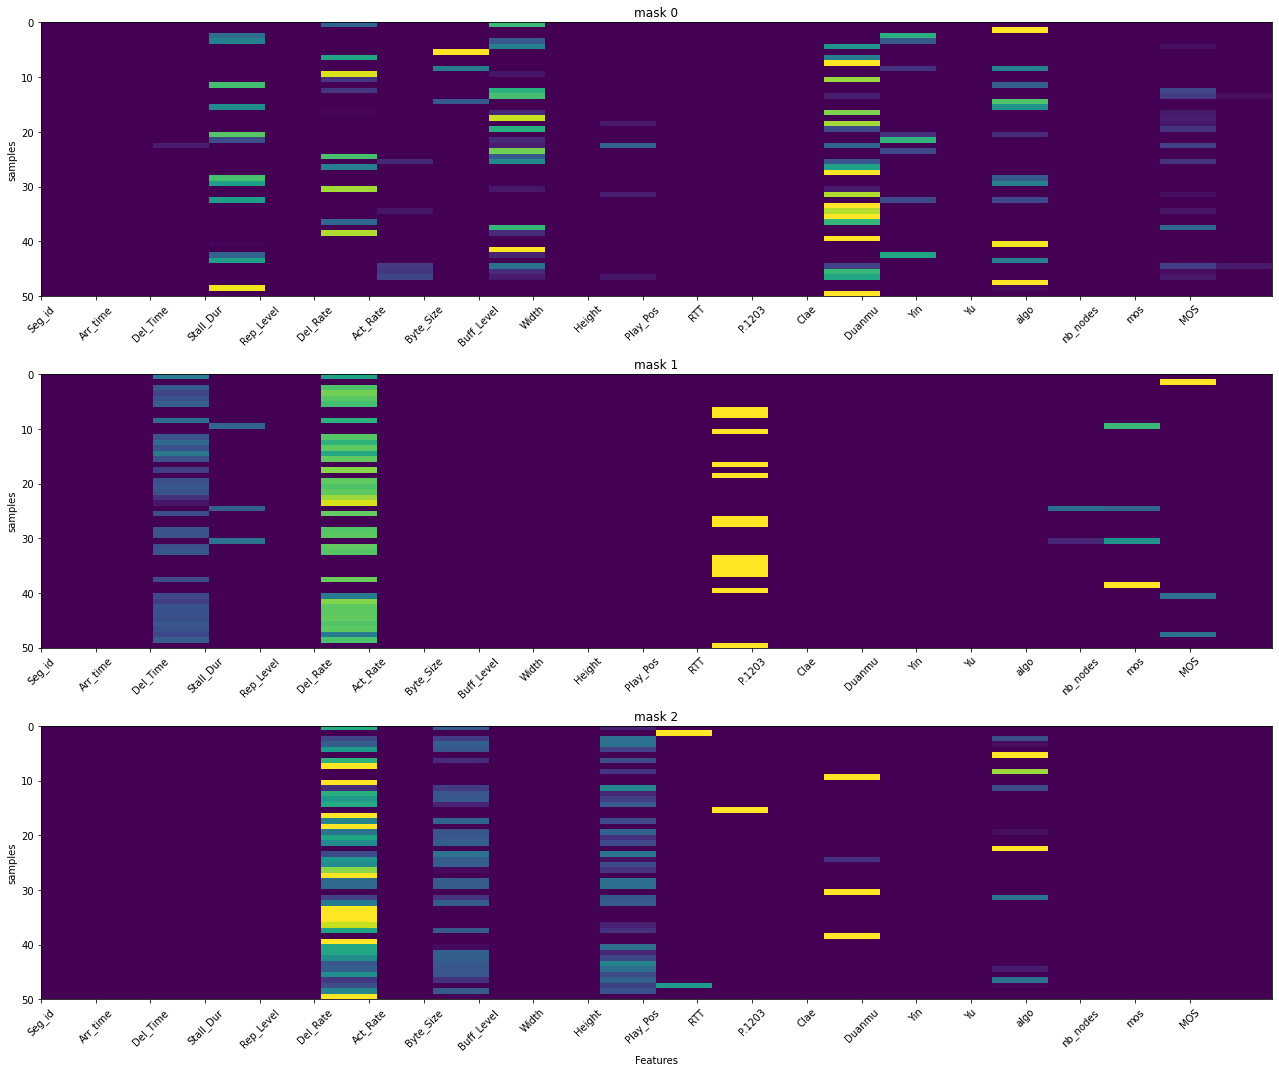

In [30]:
fig, axs = plt.subplots(3, 1, figsize=(20,15))
features_index = [x*20 for x in range(len(features))]
for i in range(3):
    axs[i].set_xticks(features_index)
    axs[i].imshow(masks[i][:50], extent=[0, 450, 50, 0], aspect=2)
    axs[i].set_xticklabels(features, rotation=45)
    axs[i].set_title(f"mask {i}")
    axs[i].set_ylabel("samples")    
axs[i].set_xlabel("Features")    
fig.tight_layout()

### _1. Using Accuracy as an Evaluation metric_ 

In [34]:
tabnet_params = {"cat_idxs":cat_idxs,
                 "cat_dims":cat_dims,
                 "cat_emb_dim":2,
                 "optimizer_fn":torch.optim.Adam,
                 "optimizer_params":dict(lr=2e-2),
                 "scheduler_params":{"step_size":50, # how to use learning rate scheduler
                                 "gamma":0.9},
                 "scheduler_fn":torch.optim.lr_scheduler.StepLR,
                 "mask_type":'entmax', # "sparsemax"
                 ##"grouped_features" : grouped_features,
                  "device_name" : "auto"                 
                }

auc_clf = TabNetClassifier(**tabnet_params)

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [35]:
max_epochs = 100 if not os.getenv("CI", False) else 2

from pytorch_tabnet.augmentations import ClassificationSMOTE
aug = ClassificationSMOTE(p=0.2)

In [36]:
# This illustrates the warm_start=False behaviour
save_history = []
start_time = time.time()

# Fitting the model without starting from a warm start nor computing the feature importance
for _ in range(2):
    auc_clf.fit(
        X_train=X_train, y_train=y_train,
        eval_set=[(X_train, y_train), (X_valid, y_valid)],
        eval_name=['train', 'valid'],
        eval_metric=['accuracy'],
        max_epochs=max_epochs , # max_epochs=11, patience=20,
        batch_size=1024, virtual_batch_size=128,
        num_workers=0,
        weights=1,
        drop_last=False,
        augmentations=aug, #aug, None
        compute_importance=True
    )
    save_history.append(auc_clf.history["valid_accuracy"])

assert(np.all(np.array(save_history[0]==np.array(save_history[1]))))

print(f"Training completed in {(time.time()-start_time)//60:.2f} mnt.")

epoch 0  | loss: 1.08349 | train_accuracy: 0.58591 | valid_accuracy: 0.58718 |  0:00:05s
epoch 1  | loss: 0.86331 | train_accuracy: 0.62681 | valid_accuracy: 0.6242  |  0:00:10s
epoch 2  | loss: 0.78786 | train_accuracy: 0.7471  | valid_accuracy: 0.74608 |  0:00:16s
epoch 3  | loss: 0.70206 | train_accuracy: 0.74771 | valid_accuracy: 0.74463 |  0:00:21s
epoch 4  | loss: 0.66444 | train_accuracy: 0.73685 | valid_accuracy: 0.73346 |  0:00:26s
epoch 5  | loss: 0.63951 | train_accuracy: 0.79108 | valid_accuracy: 0.79291 |  0:00:32s
epoch 6  | loss: 0.6199  | train_accuracy: 0.79459 | valid_accuracy: 0.79668 |  0:00:37s
epoch 7  | loss: 0.60582 | train_accuracy: 0.78962 | valid_accuracy: 0.78831 |  0:00:45s
epoch 8  | loss: 0.59201 | train_accuracy: 0.80114 | valid_accuracy: 0.80145 |  0:00:51s
epoch 9  | loss: 0.58439 | train_accuracy: 0.80304 | valid_accuracy: 0.79944 |  0:00:56s
epoch 10 | loss: 0.57607 | train_accuracy: 0.78786 | valid_accuracy: 0.7877  |  0:01:01s
epoch 11 | loss: 0.57

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


epoch 0  | loss: 1.08349 | train_accuracy: 0.58591 | valid_accuracy: 0.58718 |  0:00:05s
epoch 1  | loss: 0.86331 | train_accuracy: 0.62681 | valid_accuracy: 0.6242  |  0:00:11s
epoch 2  | loss: 0.78786 | train_accuracy: 0.7471  | valid_accuracy: 0.74608 |  0:00:16s
epoch 3  | loss: 0.70206 | train_accuracy: 0.74771 | valid_accuracy: 0.74463 |  0:00:21s
epoch 4  | loss: 0.66444 | train_accuracy: 0.73685 | valid_accuracy: 0.73346 |  0:00:26s
epoch 5  | loss: 0.63951 | train_accuracy: 0.79108 | valid_accuracy: 0.79291 |  0:00:31s
epoch 6  | loss: 0.6199  | train_accuracy: 0.79459 | valid_accuracy: 0.79668 |  0:00:37s
epoch 7  | loss: 0.60582 | train_accuracy: 0.78962 | valid_accuracy: 0.78831 |  0:00:43s
epoch 8  | loss: 0.59201 | train_accuracy: 0.80114 | valid_accuracy: 0.80145 |  0:00:48s
epoch 9  | loss: 0.58439 | train_accuracy: 0.80304 | valid_accuracy: 0.79944 |  0:00:54s
epoch 10 | loss: 0.57607 | train_accuracy: 0.78786 | valid_accuracy: 0.7877  |  0:00:59s
epoch 11 | loss: 0.57

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Training completed in 7.00 mnt.


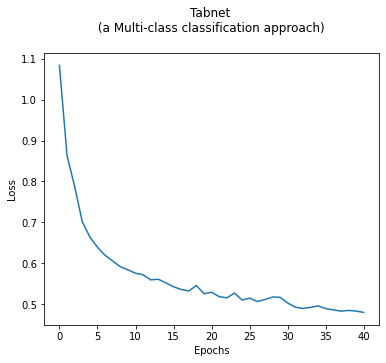

In [84]:
# plot losses
plt.figure(figsize=(6,5))
plt.plot(auc_clf.history['loss'])
plt.title('Tabnet \n (a Multi-class classification approach) \n ')
plt.xlabel('Epochs')
plt.ylabel('Loss')
#plt.legend()
plt.show()

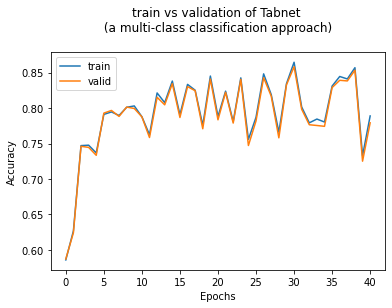

In [85]:
# plot auc
plt.plot(auc_clf.history['train_accuracy'], label="train")
plt.plot(auc_clf.history['valid_accuracy'], label="valid")

plt.title('train vs validation of Tabnet \n (a multi-class classification approach) \n ')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

##### _Evaluate_

In [87]:
from sklearn.metrics import silhouette_score, accuracy_score, mean_squared_error, r2_score

# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_valid = auc_clf.predict(X_valid)
y_pred_train = auc_clf.predict(X_train)
y_pred_test = auc_clf.predict(X_test)

# Calculate accuracy
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Validation Accuracy:", valid_accuracy)
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Validation Accuracy: 0.8583632699553141
Train Accuracy: 0.8646659364731654
Test Accuracy: 0.8610397196261682


Evaluate using test set :

In [88]:
# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_test = auc_clf.predict(X_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.8610397196261682


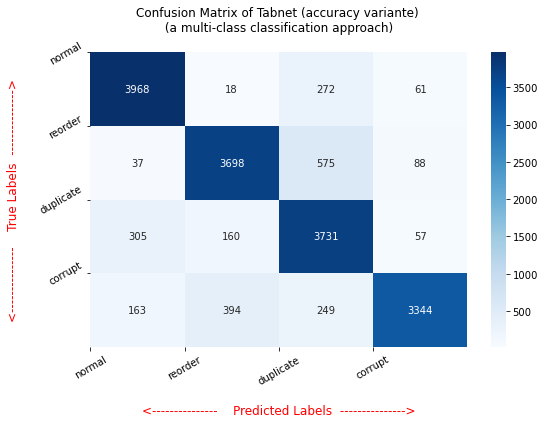

In [89]:
# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

import seaborn as sns
import matplotlib.pyplot as plt


labeled_classes = ['normal','reorder', 'duplicate','corrupt']
classes = np.unique(y_train) 

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labeled_classes, rotation=30)
plt.yticks(classes, labeled_classes, rotation=30)
plt.xlabel("<---------------    Predicted Labels  --------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<---------------    True Labels  --------------->",  fontsize=12, color="red", labelpad=18)
plt.title('Confusion Matrix of Tabnet (accuracy variante) \n (a multi-class classification approach) \n ')
plt.tight_layout()
plt.show()

In [90]:
# Display a classification report
print("                      TabNet Classification Report")
print("                (a multi-class classification approach) \n")
print(classification_report(y_test, y_pred_test))

                      TabNet Classification Report
                (a multi-class classification approach) 

              precision    recall  f1-score   support

           0       0.89      0.92      0.90      4319
           1       0.87      0.84      0.85      4398
           2       0.77      0.88      0.82      4253
           3       0.94      0.81      0.87      4150

    accuracy                           0.86     17120
   macro avg       0.87      0.86      0.86     17120
weighted avg       0.87      0.86      0.86     17120



##### _Global explainability : feat importance summing to 1_

In [91]:
scorez = auc_clf.feature_importances_

# Sort features based on their absolute coefficients
feature_importance = pd.DataFrame({'feature': features, 'score': scorez})
feature_importance = feature_importance.sort_values(by='score', ascending=False)
feature_importance['f_indice'] = feature_importance.index
feature_importance = feature_importance.reset_index().drop(["index"], axis=1)
feature_importance['rank'] = feature_importance.index+1
feature_importance.head(20)

,feature,score,f_indice,rank
0,Del_Rate,0.196221,5,1
1,Buff_Level,0.138007,8,2
2,nb_nodes,0.108004,19,3
3,P.1203,0.068076,13,4
4,Rep_Level,0.065319,4,5
5,Clae,0.058465,14,6
6,Width,0.058461,9,7
7,Arr_time,0.048898,1,8
8,Byte_Size,0.047550,7,9
9,Act_Rate,0.043254,6,10


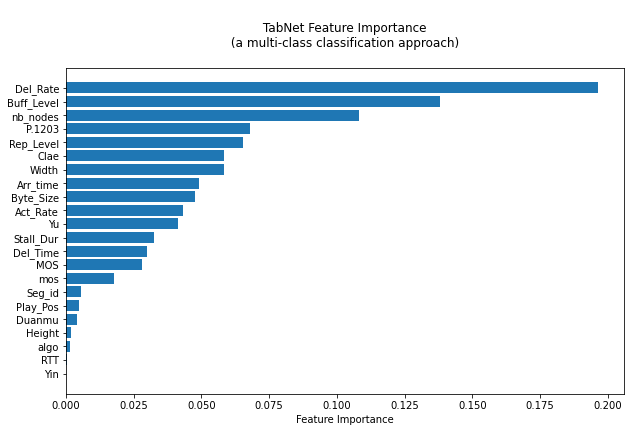

In [92]:
feature_importance = auc_clf.feature_importances_

# Map feature names to importance scores
feature_names = [features[i] for i in range(X_train.shape[1])]
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1])

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), [importance for feature, importance in sorted_features], align="center")
plt.yticks(range(len(sorted_features)), [feature for feature, importance in sorted_features])
plt.xlabel("Feature Importance")
plt.title("\n TabNet Feature Importance \n (a multi-class classification approach) \n")
plt.show()

#### _Local explainability and masks_

In [95]:
explain_matrix, masks = auc_clf.explain(X_test)
print (masks.keys())
masks[0][:50].shape

dict_keys([0, 1, 2])


(50, 22)

In [99]:
len(features)

22

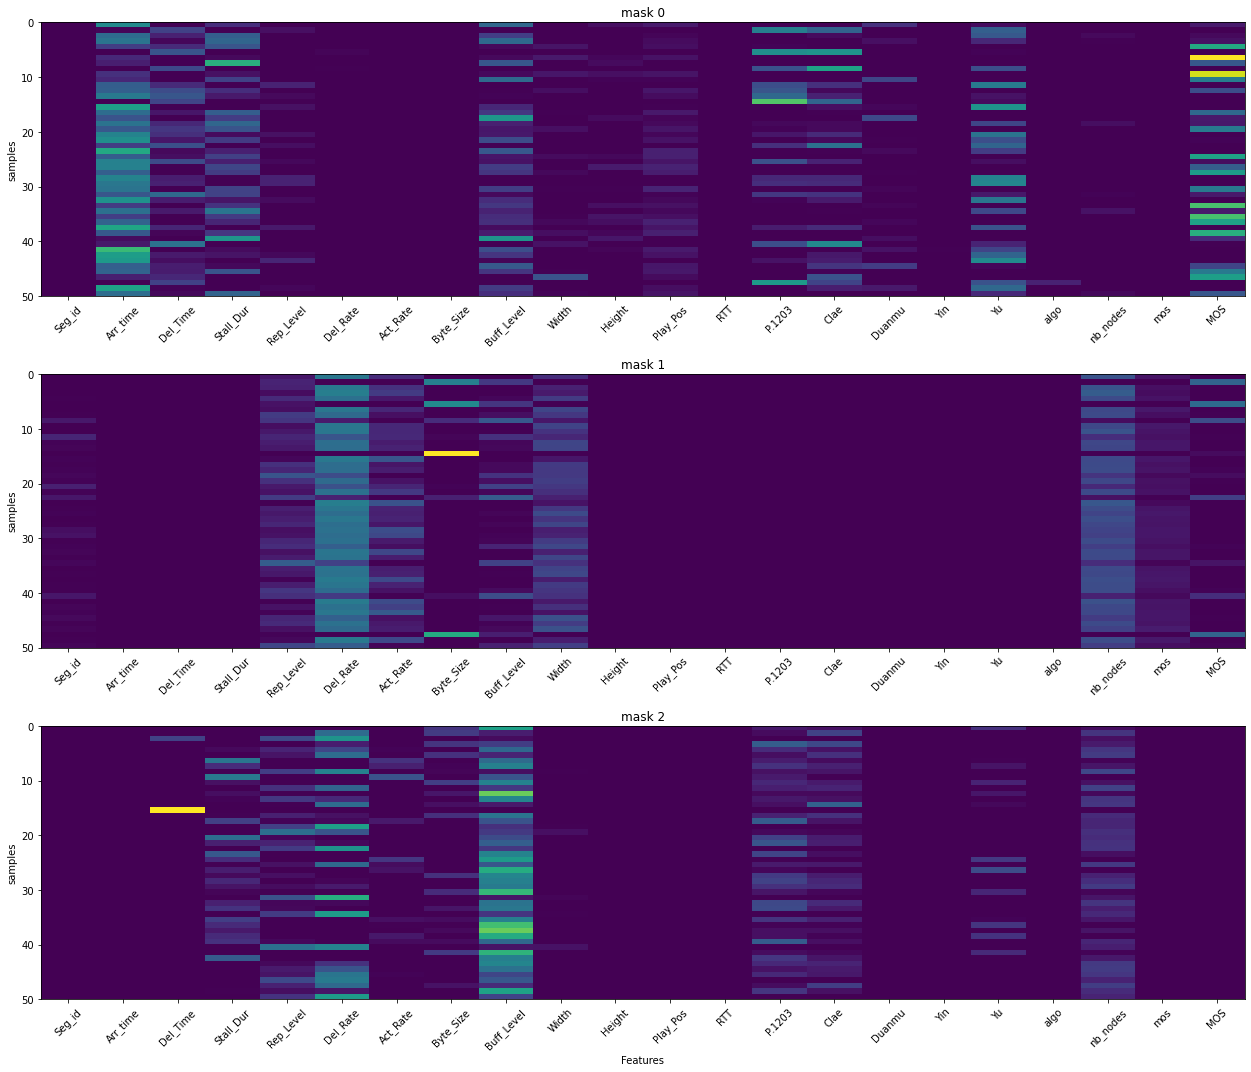

In [103]:
fig, axs = plt.subplots(3, 1, figsize=(20,15))
features_index = [x*20+10 for x in range(len(features))]
for i in range(3):
    axs[i].set_xticks(features_index)
    axs[i].imshow(masks[i][:50], extent=[0, 440, 50, 0], aspect=2)
    axs[i].set_xticklabels(features, rotation=45)
    axs[i].set_title(f"mask {i}")
    axs[i].set_ylabel("samples")    
axs[i].set_xlabel("Features")    
fig.tight_layout()

### _2. Using logloss_

In [43]:
tabnet_params = {"cat_idxs":cat_idxs,
                 "cat_dims":cat_dims,
                 "cat_emb_dim":2,
                 "optimizer_fn":torch.optim.Adam,
                 "optimizer_params":dict(lr=2e-2),
                 "scheduler_params":{"step_size":50, # how to use learning rate scheduler
                                 "gamma":0.9},
                 "scheduler_fn":torch.optim.lr_scheduler.StepLR,
                 "mask_type":'entmax', # "sparsemax"
                 # "grouped_features" : grouped_features,
                 "device_name" : "auto"                 
                }

loss_clf = TabNetClassifier(**tabnet_params)

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [44]:
# This illustrates the warm_start=False behaviour
save_history = []
start_time = time.time()

# Fitting the model without starting from a warm start nor computing the feature importance
for _ in range(2):
    loss_clf.fit(
        X_train=X_train, y_train=y_train,
        eval_set=[(X_train, y_train), (X_valid, y_valid)],
        eval_name=['train', 'valid'],
        eval_metric=['logloss'],
        max_epochs=max_epochs , # patience=20,
        batch_size=1024, virtual_batch_size=128,
        num_workers=0,
        weights=1,
        drop_last=False,
        augmentations=aug, #aug, None
        compute_importance=True
    )
    save_history.append(loss_clf.history["valid_logloss"])

assert(np.all(np.array(save_history[0]==np.array(save_history[1]))))

print(f"Training completed in {(time.time()-start_time)//60:.2f} mnt.")

epoch 0  | loss: 1.08349 | train_logloss: 0.88629 | valid_logloss: 0.88483 |  0:00:05s
epoch 1  | loss: 0.86331 | train_logloss: 0.77753 | valid_logloss: 0.77715 |  0:00:10s
epoch 2  | loss: 0.78786 | train_logloss: 0.67895 | valid_logloss: 0.67699 |  0:00:16s
epoch 3  | loss: 0.70206 | train_logloss: 0.62793 | valid_logloss: 0.62875 |  0:00:21s
epoch 4  | loss: 0.66444 | train_logloss: 0.62775 | valid_logloss: 0.63    |  0:00:27s
epoch 5  | loss: 0.63951 | train_logloss: 0.53411 | valid_logloss: 0.53558 |  0:00:33s
epoch 6  | loss: 0.6199  | train_logloss: 0.53074 | valid_logloss: 0.52861 |  0:00:38s
epoch 7  | loss: 0.60582 | train_logloss: 0.54582 | valid_logloss: 0.54556 |  0:00:44s
epoch 8  | loss: 0.59201 | train_logloss: 0.51441 | valid_logloss: 0.51298 |  0:00:50s
epoch 9  | loss: 0.58439 | train_logloss: 0.51085 | valid_logloss: 0.51149 |  0:00:56s
epoch 10 | loss: 0.57607 | train_logloss: 0.53074 | valid_logloss: 0.53415 |  0:01:03s
epoch 11 | loss: 0.57213 | train_logloss: 0

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


epoch 0  | loss: 1.08349 | train_logloss: 0.88629 | valid_logloss: 0.88483 |  0:00:06s
epoch 1  | loss: 0.86331 | train_logloss: 0.77753 | valid_logloss: 0.77715 |  0:00:13s
epoch 2  | loss: 0.78786 | train_logloss: 0.67895 | valid_logloss: 0.67699 |  0:00:19s
epoch 3  | loss: 0.70206 | train_logloss: 0.62793 | valid_logloss: 0.62875 |  0:00:25s
epoch 4  | loss: 0.66444 | train_logloss: 0.62775 | valid_logloss: 0.63    |  0:00:31s
epoch 5  | loss: 0.63951 | train_logloss: 0.53411 | valid_logloss: 0.53558 |  0:00:37s
epoch 6  | loss: 0.6199  | train_logloss: 0.53074 | valid_logloss: 0.52861 |  0:00:43s
epoch 7  | loss: 0.60582 | train_logloss: 0.54582 | valid_logloss: 0.54556 |  0:00:49s
epoch 8  | loss: 0.59201 | train_logloss: 0.51441 | valid_logloss: 0.51298 |  0:00:55s
epoch 9  | loss: 0.58439 | train_logloss: 0.51085 | valid_logloss: 0.51149 |  0:01:01s
epoch 10 | loss: 0.57607 | train_logloss: 0.53074 | valid_logloss: 0.53415 |  0:01:08s
epoch 11 | loss: 0.57213 | train_logloss: 0

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Training completed in 8.00 mnt.


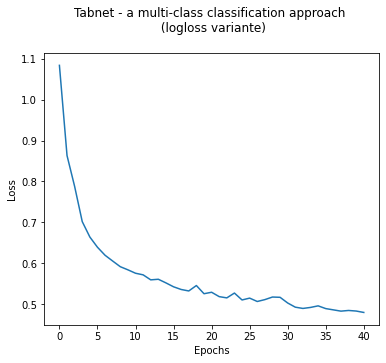

In [58]:
# plot losses
plt.figure(figsize=(6,5))
plt.plot(loss_clf.history['loss'])
plt.title('Tabnet - a multi-class classification approach \n (logloss variante)\n')
plt.xlabel('Epochs')
plt.ylabel('Loss')
#plt.legend()
plt.show()

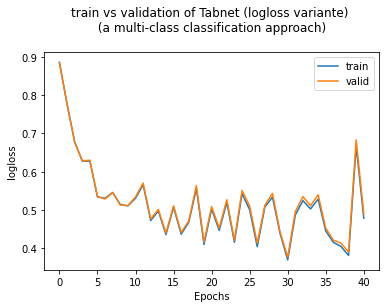

In [59]:
# plot logloss
plt.plot(loss_clf.history['train_logloss'], label="train")
plt.plot(loss_clf.history['valid_logloss'], label="valid")
plt.title('train vs validation of Tabnet (logloss variante) \n (a multi-class classification approach) \n ')
plt.xlabel('Epochs')
plt.ylabel('logloss')
plt.legend()

In [60]:
# check that best weights are used
# assert np.isclose(valid_auc, np.max(clf.history['valid_logloss']), atol=1e-6)

In [61]:
loss_clf.predict(X_test)

array([2, 3, 1, ..., 0, 1, 3], dtype=int64)

##### _Evaluate_

In [62]:
from sklearn.metrics import silhouette_score, accuracy_score, mean_squared_error, r2_score

# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_valid = loss_clf.predict(X_valid)
y_pred_train = loss_clf.predict(X_train)
y_pred_test = loss_clf.predict(X_test)

# Calculate accuracy
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Validation Accuracy:", valid_accuracy)
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Validation Accuracy: 0.8583632699553141
Train Accuracy: 0.8646659364731654
Test Accuracy: 0.8610397196261682


Evaluate using test set :

In [63]:
# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_test = loss_clf.predict(X_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.8610397196261682


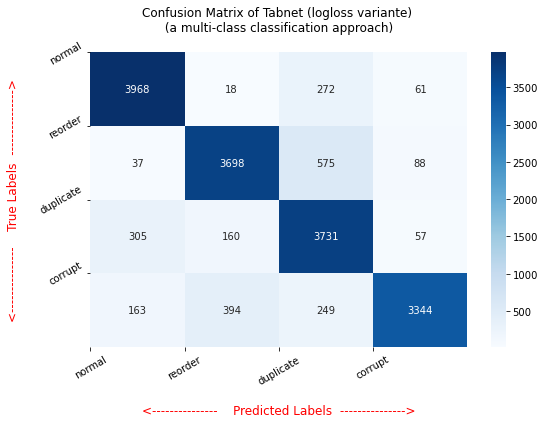

In [65]:
# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

import seaborn as sns
import matplotlib.pyplot as plt


labeled_classes = ['normal','reorder', 'duplicate','corrupt']
classes = np.unique(y_train) 

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labeled_classes, rotation=30)
plt.yticks(classes, labeled_classes, rotation=30)
plt.xlabel("<---------------    Predicted Labels  --------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<---------------    True Labels  --------------->",  fontsize=12, color="red", labelpad=18)
plt.title('Confusion Matrix of Tabnet (logloss variante) \n (a multi-class classification approach) \n ')
plt.tight_layout()
plt.show()

In [66]:
# Display a classification report
print("            TabNet Classification Report")
print("                (a multi-class classification approach) \n")
print(classification_report(y_test, y_pred_test))

            TabNet Classification Report
                (a multi-class classification approach) 

              precision    recall  f1-score   support

           0       0.89      0.92      0.90      4319
           1       0.87      0.84      0.85      4398
           2       0.77      0.88      0.82      4253
           3       0.94      0.81      0.87      4150

    accuracy                           0.86     17120
   macro avg       0.87      0.86      0.86     17120
weighted avg       0.87      0.86      0.86     17120



#### _Global explainability : feat importance summing to 1_

In [67]:
scorez = loss_clf.feature_importances_

# Sort features based on their absolute coefficients
feature_importance = pd.DataFrame({'feature': features, 'score': scorez})
feature_importance = feature_importance.sort_values(by='score', ascending=False)
feature_importance['f_indice'] = feature_importance.index
feature_importance = feature_importance.reset_index().drop(["index"], axis=1)
feature_importance['rank'] = feature_importance.index+1
feature_importance.head(20)

,feature,score,f_indice,rank
0,Del_Rate,0.196221,5,1
1,Buff_Level,0.138007,8,2
2,nb_nodes,0.108004,19,3
3,P.1203,0.068076,13,4
4,Rep_Level,0.065319,4,5
5,Clae,0.058465,14,6
6,Width,0.058461,9,7
7,Arr_time,0.048898,1,8
8,Byte_Size,0.047550,7,9
9,Act_Rate,0.043254,6,10


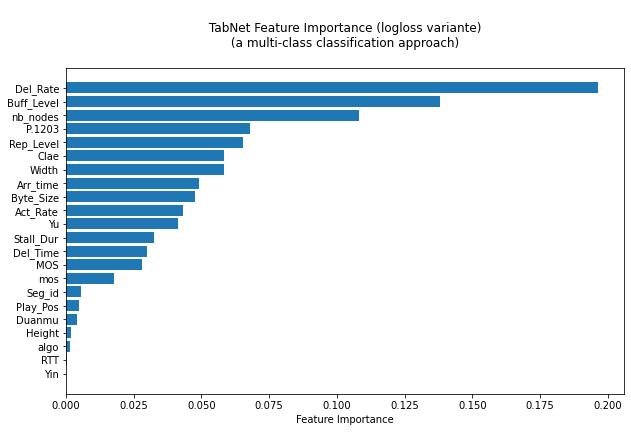

In [69]:
feature_importance = loss_clf.feature_importances_

# Map feature names to importance scores
# feature_names = [f'Feature {i}' for i in range(X_train.shape[1])]
feature_names = [features[i] for i in range(X_train.shape[1])]
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1])

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), [importance for feature, importance in sorted_features], align="center")
plt.yticks(range(len(sorted_features)), [feature for feature, importance in sorted_features])
plt.xlabel("Feature Importance")
plt.title("\n TabNet Feature Importance (logloss variante) \n (a multi-class classification approach) \n")
plt.show()

#### _Local explainability and masks_

In [70]:
explain_matrix, masks = loss_clf.explain(X_test)
print (masks.keys())
masks[0][:50].shape

dict_keys([0, 1, 2])


(50, 22)

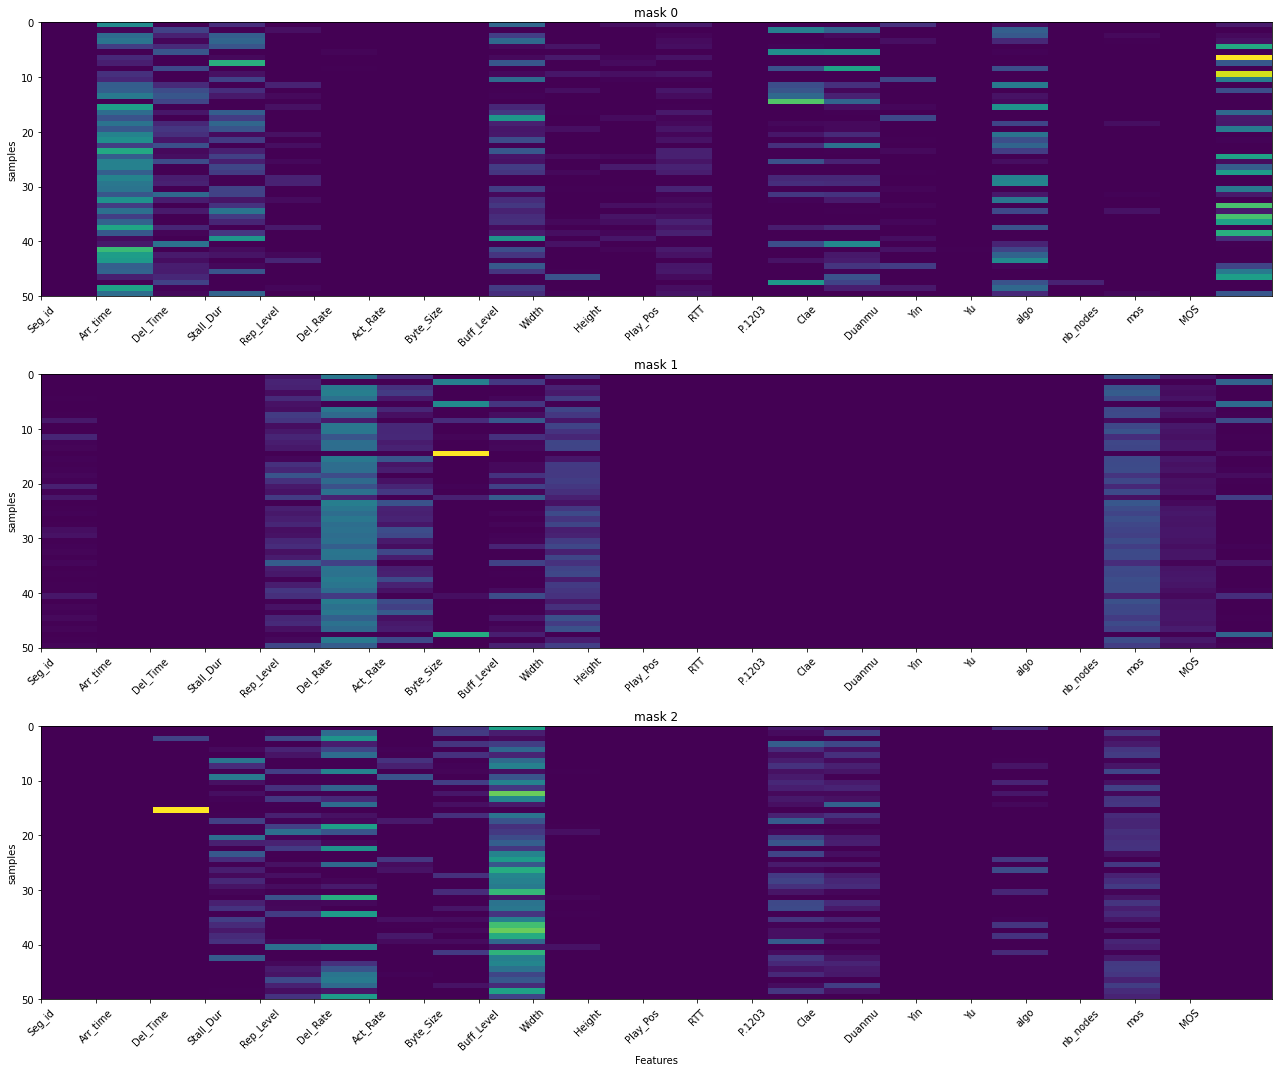

In [71]:
fig, axs = plt.subplots(3, 1, figsize=(20,15))
features_index = [x*20+10 for x in range(len(features))]
for i in range(3):
    axs[i].set_xticks(features_index)
    axs[i].imshow(masks[i][:50], extent=[0, 440, 50, 0], aspect=2)
    # axs[i].set(xticks=np.linspace(0, 23), xticklabels=np.linspace(0, 23), yticks=[0, 50], yticklabels=[0, 1]);    
    axs[i].set_xticklabels(features, rotation=45)
    axs[i].set_title(f"mask {i}")
    axs[i].set_ylabel("samples")    
axs[i].set_xlabel("Features")    
fig.tight_layout()

_**c. Discussion**_

As we saw in the results, using either accuracy or logloss does not has a considerable impact on the performance of our TabNet model.

Nevertheless, considering the little enhancement given by "accuracy", we pick it as a representative of TabNet in multi-class anomaly detection approach.